# 02 — Bulk RNA-seq Differential Expression

This notebook walks through **bulk RNA-seq** for **human iPSC–derived cardiac fibroblasts** stimulated with cytokines (Alexanian et al., *Nature* 2024). The headline biological readout we connect to the paper is **Fig. 5B**: **_MEOX1_** sitting in the **TGFB + IL1B** quadrant—meaning a strong response to **TGFB** and an additional shift when **IL1B** is present together with TGFB.

**Run on: ARM64** — Uses paired-end FASTQs produced by **`scripts/python/download_data.py`**. This track is separate from **Cell Ranger** (single-cell) data in the same study.

**Design:** four conditions × four biological replicates (**16** SRA runs): Unstim, IL1B, TGFB, and TGFB+IL1B.

**In brief:** align to **hg38**, aggregate to **gene-level counts** with **featureCounts** (Ensembl exons), then run **limma–voom** for two contrasts that match the TGFB / combination story above.

## Data paths

GEO **GSE221699** / BioProject **PRJNA915384** contains many libraries; this notebook uses only the **16 bulk RNA-seq** accessions **SRR22882084–SRR22882099** (not the 10× single-cell runs).

After download, each accession should be a folder **`data/<SRR>/`** containing **`_1.fastq.gz`** and **`_2.fastq.gz`**. The next cell counts how many of those folders exist so you can align **as soon as each pair is complete** (or resume after a partial download).

**Note:** if **Rsubread** aborts on one SRR while others succeed, suspect a **truncated or corrupt FASTQ**—check file sizes and re-download that run if needed.

### Running this notebook

Use a Jupyter **R** kernel (IRkernel) with **Rsubread**, **edgeR**, and **limma** installed—see **`INSTALL.md`**. Paths are set relative to the **`notebooks/`** directory (`..` → project root).

In [1]:
# Check data availability (use R kernel)
bulk_runs <- sprintf("SRR228820%02d", 84:99)
n_available <- sum(dir.exists(file.path("../data", bulk_runs)))
cat("Available:", n_available, "/ 16 bulk RNA-seq runs\n")
if (n_available > 0) {
  first <- bulk_runs[dir.exists(file.path("../data", bulk_runs))][1]
  cat("Sample:", first, "->", paste(head(list.files(file.path("../data", first)), 2), collapse = ", "), "\n")
}

Available: 16 / 16 bulk RNA-seq runs
Sample: SRR22882084 -> SRR22882084_1.fastq.gz, SRR22882084_2.fastq.gz 


## Pipeline

End-to-end steps (after **`download_data.py`**):

1. **Reference (hg38):** Ensembl **GRCh38** primary assembly **FASTA** + matching **GTF** (human—not mouse; these fibroblasts are **Homo sapiens**).
2. **Index:** **Rsubread** `buildindex` **once**; reused for every sample.
3. **Align:** **Rsubread** `align` (RNA mode) → one **BAM per SRR** under **`output/bulk_rnaseq/bams/`**; existing BAMs are skipped.
4. **Count:** **featureCounts** assigns reads to **exons** and sums to **gene_id** (Ensembl `ENSG...`).
5. **DE:** **edgeR** + **limma–voom**: TMM normalization, **voom** mean–variance modeling, contrasts **TGFB vs Unstim** and **TGFB+IL1B vs TGFB**.
6. **Fig. 5B–style check:** **_MEOX1_** (**`ENSG00000125510`**) — expect a strong **TGFB** signature and an additional positive **logFC** when comparing **TGFB+IL1B** to **TGFB** alone (synergistic quadrant in the paper).

### Reference genome (hg38)

We use Ensembl’s **GRCh38** “**dna.primary_assembly**” FASTA: it includes the main chromosomes without the bulk of alternate loci, which keeps the aligner index smaller and reduces reads mapping to redundant haplotypes.

The **GTF** supplies **exon–gene** structure for **featureCounts**. **Release 110** is fixed in the URLs so FASTA and annotation stay in sync (chromosome names and feature coordinates match).

**Download once** if missing (~0.88 GB + ~50 MB). **Rsubread** accepts **`.gz`** directly. Files are written under **`data/reference/`** (alongside per-SRR folders under **`data/`**).

In [2]:
# Paths (relative to notebook dir)
data_dir <- file.path("..", "data")
ref_dir <- file.path("..", "data", "reference")
out_dir <- file.path("..", "output", "bulk_rnaseq")
dir.create(ref_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# Reference files (Ensembl release 110)
ensembl_release <- "110"
fa_url <- paste0("http://ftp.ensembl.org/pub/release-", ensembl_release, "/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz")
gtf_url <- paste0("http://ftp.ensembl.org/pub/release-", ensembl_release, "/gtf/homo_sapiens/Homo_sapiens.GRCh38.", ensembl_release, ".gtf.gz")
fa_gz <- file.path(ref_dir, basename(fa_url))
gtf_gz <- file.path(ref_dir, basename(gtf_url))

# Download if missing (~880 MB FASTA, ~50 MB GTF). Rsubread accepts .gz directly.
# Increase timeout for large files (default 60s is too short)
options(timeout = 7200)  # 2 hours

# Remove incomplete partial download if present
expected_fa_size <- 881e6  # ~881 MB
if (file.exists(fa_gz) && file.info(fa_gz)$size < expected_fa_size) {
  message("Removing incomplete FASTA (", round(file.info(fa_gz)$size/1e6, 1), " MB)")
  unlink(fa_gz)
}

if (!file.exists(fa_gz)) {
  message("Downloading hg38 FASTA (~880 MB, may take 10-30 min)...")
  download.file(fa_url, fa_gz, mode = "wb")
}
if (!file.exists(gtf_gz)) {
  message("Downloading hg38 GTF...")
  download.file(gtf_url, gtf_gz, mode = "wb")
}

fa_path <- fa_gz
gtf_path <- gtf_gz
cat("FASTA:", fa_path, "exists:", file.exists(fa_path), "\n")
cat("GTF:", gtf_path, "exists:", file.exists(gtf_path), "\n")

FASTA: ../data/reference/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz exists: TRUE 
GTF: ../data/reference/Homo_sapiens.GRCh38.110.gtf.gz exists: TRUE 


### Build index and align (Rsubread)

**`buildindex`** writes several index files prefixed **`hg38_ens110`** under **`data/reference/`**. The code treats presence of **`.00.b.tab`** as “index created.”

**`align`** maps paired FASTQs from each **`data/<SRR>/`** to that index and writes **`output/bulk_rnaseq/bams/<SRR>.bam`**. Runs missing either mate are skipped; runs with an existing BAM print **Skip (exists)** so you can **restart** long jobs safely.

**Threads:** `parallel::detectCores()` — lower manually if you need to share the machine. **Runtime** is on the order of **~tens of minutes per sample** depending on depth and CPU.

Requires an **R** kernel with the **Rsubread** package installed.

In [4]:
library(Rsubread)

# Index path (build once)
index_prefix <- file.path(ref_dir, "hg38_ens110")
bam_dir <- file.path(out_dir, "bams")
dir.create(bam_dir, recursive = TRUE, showWarnings = FALSE)

# Build index if not present
if (!file.exists(paste0(index_prefix, ".00.b.tab"))) {
  message("Building Rsubread index for hg38...")
  buildindex(basename = index_prefix, reference = fa_path)
}

# Process only available runs
bulk_runs <- sprintf("SRR228820%02d", 84:99)
available <- bulk_runs[dir.exists(file.path(data_dir, bulk_runs))]
cat("Aligning", length(available), "/ 16 samples\n")

for (run in available) {
  run_dir <- file.path(data_dir, run)
  fq1 <- file.path(run_dir, paste0(run, "_1.fastq.gz"))
  fq2 <- file.path(run_dir, paste0(run, "_2.fastq.gz"))
  out_bam <- file.path(bam_dir, paste0(run, ".bam"))
  if (!file.exists(fq1) || !file.exists(fq2)) next
  if (file.exists(out_bam)) { cat("Skip (exists):", run, "\n"); next }
  message("Aligning ", run, " ...")
  align(index = index_prefix, readfile1 = fq1, readfile2 = fq2,
        output_file = out_bam, nthreads = parallel::detectCores(), type = "rna")
}

Aligning 16 / 16 samples
Skip (exists): SRR22882084 
Skip (exists): SRR22882085 
Skip (exists): SRR22882086 
Skip (exists): SRR22882087 
Skip (exists): SRR22882088 
Skip (exists): SRR22882089 
Skip (exists): SRR22882090 
Skip (exists): SRR22882091 


Aligning SRR22882092 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (RNA-Seq)                                   ||
|| Input file 1  : SRR22882092_1.fastq.gz                                     ||
|| Input file 2  : SRR22882092_2.fastq.gz                                     ||
|| Output file   : SRR22882092.bam (BAM)                                      ||
|| Index name    : hg38_ens110                      

Aligning SRR22882093 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (RNA-Seq)                                   ||
|| Input file 1  : SRR22882093_1.fastq.gz                                     ||
|| Input file 2  : SRR22882093_2.fastq.gz                                     ||
|| Output file   : SRR22882093.bam (BAM)                                      ||
|| Index name    : hg38_ens110                      

...


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (RNA-Seq)                                   ||
|| Input file 1  : SRR22882097_1.fastq.gz                                     ||
|| Input file 2  : SRR22882097_2.fastq.gz                                     ||
|| Output file   : SRR22882097.bam (BAM)                                      ||
|| Index name    : hg38_ens110                      

Aligning SRR22882098 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (RNA-Seq)                                   ||
|| Input file 1  : SRR22882098_1.fastq.gz                                     ||
|| Input file 2  : SRR22882098_2.fastq.gz                                     ||
|| Output file   : SRR22882098.bam (BAM)                                      ||
|| Index name    : hg38_ens110                      

Aligning SRR22882099 ...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//================================= setting ==================================\\
||                                                                            ||
|| Function      : Read alignment (RNA-Seq)                                   ||
|| Input file 1  : SRR22882099_1.fastq.gz                                     ||
|| Input file 2  : SRR22882099_2.fastq.gz                                     ||
|| Output file   : SRR22882099.bam (BAM)                                      ||
|| Index name    : hg38_ens110                      

### featureCounts → count matrix

**featureCounts** (Rsubread/Subread) reads all **`.bam`** files in **`output/bulk_rnaseq/bams/`**, overlaps them with **exons** from the same **GTF** as alignment, and outputs a **genes × samples** matrix. Here **`GTF.featureType = "exon"`** and **`GTF.attrType = "gene_id"`** mean counts are summed to **Ensembl gene IDs** (`ENSG...`) — standard for RNA-seq DE.

**`isPairedEnd = TRUE`** counts fragments (pairs) appropriately. Column names are shortened to **`SRR...`** to match **`samples$run`** below.

The table is saved as **`output/bulk_rnaseq/bulk_counts.txt`**. Re-run after adding BAMs. If this cell says there are no BAMs yet, run the alignment cell first.

## Interpretation (what this bulk RNA-seq shows)

This analysis connects the paper’s **fibroblast activation** claim to a quantitative bulk RNA-seq result.

- **TGFB vs Unstim** captures the *fibroblast activation / pro-fibrotic program*.
- **TGFB+IL1B vs TGFB** isolates the *incremental effect of inflammatory IL1B on top of TGFB* (immune → fibroblast crosstalk component).

**How to interpret the two-contrast logic (Fig 5B-style):**

If you plot each gene as a point with:

- x-axis = \(\log_2\mathrm{FC}(\mathrm{TGFB} \;vs\; \mathrm{Unstim})\)
- y-axis = \(\log_2\mathrm{FC}(\mathrm{TGFB+IL1B} \;vs\; \mathrm{TGFB})\)

then genes in the **upper-right** are both **TGFB-induced** *and* **further boosted by IL1B**, matching the “synergy / amplification” narrative in the paper.

We highlight **MEOX1** because the study uses it as a key fibroblast regulatory switch downstream of inflammatory signaling.

In [ ]:
# Slide-ready plots + small tables (requires tgfb_res and tgfb_il1b_res from limma–voom cell)
suppressPackageStartupMessages({
  library(ggplot2)
})

if (!exists("tgfb_res") || !exists("tgfb_il1b_res")) {
  message("Run the limma–voom DE cell first so tgfb_res / tgfb_il1b_res exist.")
} else {
  # Ensure gene IDs are a column
  tgfb_res$gene_id <- rownames(tgfb_res)
  tgfb_il1b_res$gene_id <- rownames(tgfb_il1b_res)

  # Merge the two contrasts by gene_id
  df <- merge(
    tgfb_res[, c("gene_id", "logFC", "adj.P.Val")],
    tgfb_il1b_res[, c("gene_id", "logFC", "adj.P.Val")],
    by = "gene_id",
    suffixes = c("_TGFB_vs_Unstim", "_TGFBIL1B_vs_TGFB")
  )

  meox1_id <- "ENSG00000125510"
  df$is_meox1 <- df$gene_id == meox1_id

  # --- Fig 5B-style scatter ---
  p_scatter <- ggplot(df, aes(x = logFC_TGFB_vs_Unstim, y = logFC_TGFBIL1B_vs_TGFB)) +
    geom_hline(yintercept = 0, color = "grey75") +
    geom_vline(xintercept = 0, color = "grey75") +
    geom_point(alpha = 0.35, size = 1) +
    geom_point(data = subset(df, is_meox1), color = "red", size = 2) +
    labs(
      title = "Fig 5B-style view: TGFB effect vs IL1B-on-TGFB effect",
      x = "log2FC (TGFB vs Unstim)",
      y = "log2FC (TGFB+IL1B vs TGFB)"
    ) +
    theme_classic()

  print(p_scatter)

  # --- Volcano: TGFB+IL1B vs TGFB ---
  vdf <- tgfb_il1b_res
  vdf$gene_id <- rownames(vdf)
  vdf$is_meox1 <- vdf$gene_id == meox1_id
  vdf$neglog10FDR <- -log10(pmax(vdf$adj.P.Val, 1e-300))

  p_volcano <- ggplot(vdf, aes(x = logFC, y = neglog10FDR)) +
    geom_point(alpha = 0.35, size = 1) +
    geom_point(data = subset(vdf, is_meox1), color = "red", size = 2) +
    labs(
      title = "Volcano: TGFB+IL1B vs TGFB (incremental IL1B effect)",
      x = "log2FC",
      y = "-log10(FDR)"
    ) +
    theme_classic()

  print(p_volcano)

  # --- Small tables for slides ---
  top10_il1b <- head(vdf[order(vdf$adj.P.Val, -abs(vdf$logFC)), c("gene_id", "logFC", "adj.P.Val")], 10)
  print(top10_il1b)

  # Save CSVs for easy slide/table import
  out_dir <- file.path("..", "output", "bulk_rnaseq")
  dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
  write.csv(tgfb_res, file = file.path(out_dir, "DE_TGFB_vs_Unstim_limma_voom.csv"), row.names = TRUE)
  write.csv(tgfb_il1b_res, file = file.path(out_dir, "DE_TGFBIL1B_vs_TGFB_limma_voom.csv"), row.names = TRUE)
  write.csv(df, file = file.path(out_dir, "DE_scatter_TGFB_vs_Unstim__TGFBIL1B_vs_TGFB.csv"), row.names = FALSE)

  # One-line talk takeaway for MEOX1
  if (meox1_id %in% rownames(tgfb_res) && meox1_id %in% rownames(tgfb_il1b_res)) {
    cat(
      "\nTalk takeaway: MEOX1 shows log2FC(TGFB vs Unstim)=", round(tgfb_res[meox1_id, "logFC"], 2),
      ", and log2FC(TGFB+IL1B vs TGFB)=", round(tgfb_il1b_res[meox1_id, "logFC"], 2),
      ".\n",
      sep = ""
    )
  }
}

In [5]:
# Count matrix output
counts_file <- file.path(out_dir, "bulk_counts.txt")

bams <- list.files(bam_dir, pattern = "\\.bam$", full.names = TRUE)
if (length(bams) == 0) {
  message("No BAMs yet. Run alignment cell above first.")
} else {
  message("Counting ", length(bams), " BAMs...")
  fc <- featureCounts(files = bams, annot.ext = gtf_path, isGTFAnnotationFile = TRUE,
                     GTF.featureType = "exon", GTF.attrType = "gene_id",
                     isPairedEnd = TRUE, nthreads = parallel::detectCores())
  counts <- fc$counts
  colnames(counts) <- sub("\\.bam$", "", basename(colnames(counts)))
  write.table(counts, counts_file, sep = "\t", quote = FALSE)
  cat("Saved:", counts_file, "\n")
}

Counting 16 BAMs...




        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
       Rsubread 2.24.0

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 16 BAM files                                     ||
||                                                                            ||
||                           SRR22882084.bam                                  ||
||                           SRR22882085.bam                                  ||
||                           SRR22882086.bam        

## Design and sample metadata

The **`samples`** `data.frame` lists all **16 SRR** IDs in the same order as the experimental layout: **four replicates** of **Unstim**, then **IL1B**, then **TGFB**, then **TGFB_IL1B** (underscore matches the factor levels used in **limma**).

**`condition`** must match the column names in the model **`~ 0 + condition`** downstream (`Unstim`, `IL1B`, `TGFB`, `TGFB_IL1B`). If you ever drop samples, try to keep **replication within each condition**; the DE cell warns if fewer than **eight** samples remain.

In [6]:
# Sample metadata for bulk RNA-seq
samples <- data.frame(
  run = paste0("SRR228820", 84:99),
  condition = rep(c("Unstim", "IL1B", "TGFB", "TGFB_IL1B"), each = 4),
  replicate = rep(1:4, 4)
)
print(samples)

           run condition replicate
1  SRR22882084    Unstim         1
2  SRR22882085    Unstim         2
3  SRR22882086    Unstim         3
4  SRR22882087    Unstim         4
5  SRR22882088      IL1B         1
6  SRR22882089      IL1B         2
7  SRR22882090      IL1B         3
8  SRR22882091      IL1B         4
9  SRR22882092      TGFB         1
10 SRR22882093      TGFB         2
11 SRR22882094      TGFB         3
12 SRR22882095      TGFB         4
13 SRR22882096 TGFB_IL1B         1
14 SRR22882097 TGFB_IL1B         2
15 SRR22882098 TGFB_IL1B         3
16 SRR22882099 TGFB_IL1B         4


## DE analysis (limma–voom)

**Requires** `bulk_counts.txt` from **featureCounts**. The code keeps only samples that appear in **both** **`samples`** and the count matrix columns.

**Normalization:** **`DGEList`** + **`calcNormFactors`** (TMM scaling). **voom** converts counts to **log–CPM** with observation-level weights so **linear modeling** is appropriate. **`~ 0 + condition`** gives one coefficient per condition (no intercept); contrasts are explicit differences.

**Contrasts:**

- **`TGFB_vs_Unstim`** — effect of TGFB vs unstimulated baseline.
- **`TGFB_IL1B_vs_TGFB`** — effect of adding IL1B **on top of** TGFB (combination vs TGFB alone).

**`eBayes`** moderates gene-wise variances. **`topTable(..., n = Inf)`** returns all genes; use **P.Value** / **adj.P.Val** for discovery.

**MEOX1:** the code extracts Ensembl **`ENSG00000125510`**. Compare the printed **logFC** values to the story in Fig. 5B (strong **TGFB** response; **additional** positive shift in **TGFB+IL1B vs TGFB**). Inspect the full **`topTable`** outputs for genome-wide context.

Loading required package: limma



MEOX1 TGFB vs Unstim logFC: -0.92 
MEOX1 TGFB+IL1B vs TGFB logFC: 0.91 


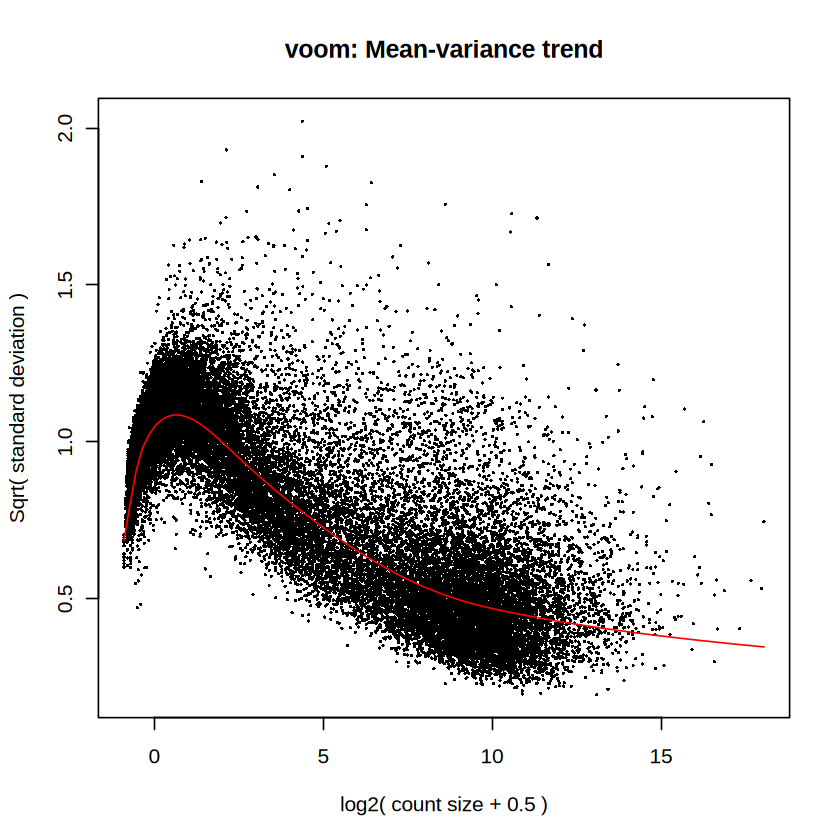

In [7]:
library(edgeR)
library(limma)

counts_file <- file.path("..", "output", "bulk_rnaseq", "bulk_counts.txt")
if (!file.exists(counts_file)) {
  message("Run featureCounts cell first to create ", counts_file)
} else {
  counts <- read.delim(counts_file, row.names = 1, check.names = FALSE)
  # Subset to samples in count matrix
  keep <- samples$run %in% colnames(counts)
  if (sum(keep) < 8) {
    message("Need at least 8 samples (2 per condition) for DE. Have ", sum(keep))
  } else {
    samples_sub <- samples[keep, ]
    counts_sub <- counts[, samples_sub$run, drop = FALSE]
    design <- model.matrix(~ 0 + condition, data = samples_sub)
    colnames(design) <- gsub("condition", "", colnames(design))

    dge <- DGEList(counts = counts_sub, samples = samples_sub)
    dge <- calcNormFactors(dge)
    v <- voom(dge, design, plot = TRUE)
    fit <- lmFit(v, design)

    cont <- makeContrasts(TGFB_vs_Unstim = TGFB - Unstim,
                         TGFB_IL1B_vs_TGFB = TGFB_IL1B - TGFB, levels = design)
    fit2 <- contrasts.fit(fit, cont)
    fit2 <- eBayes(fit2)

    tgfb_res <- topTable(fit2, coef = 1, n = Inf)
    tgfb_il1b_res <- topTable(fit2, coef = 2, n = Inf)

    # MEOX1: expect LogFC > 2 in TGFB, positive in TGFB_IL1B vs TGFB
    meox1_tgfb <- tgfb_res["ENSG00000125510", ]  # MEOX1
    meox1_il1b <- tgfb_il1b_res["ENSG00000125510", ]
    cat("MEOX1 TGFB vs Unstim logFC:", round(meox1_tgfb$logFC, 2), "\n")
    cat("MEOX1 TGFB+IL1B vs TGFB logFC:", round(meox1_il1b$logFC, 2), "\n")
  }
}

### Optional extensions

With **`fit2`** and **`tgfb_res`** / **`tgfb_il1b_res`** (or full **`topTable`** outputs), you can add **volcano plots**, **MA plots**, export CSVs for **Gene Ontology** / pathway tools, or visualize **heatmaps** of top DE genes—all using standard **limma** and plotting workflows. The **`voom`** mean–variance plot (`plot = TRUE`) is useful to confirm the transformation looks reasonable before trusting linear-model *p*-values.